In [1]:
from pathlib import Path
import os
import sys

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler


import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

In [2]:
# from google . colab import drive
# drive.mount("/content/drive/", force_remount=True)


In [3]:
# drive_path="/content/drive/MyDrive/Dataset/"
# prefix_path="."
# !cp -r $drive_path $prefix_path

In [50]:
original_or_sr = "original"
prefix_path = "../Srinivasan/"

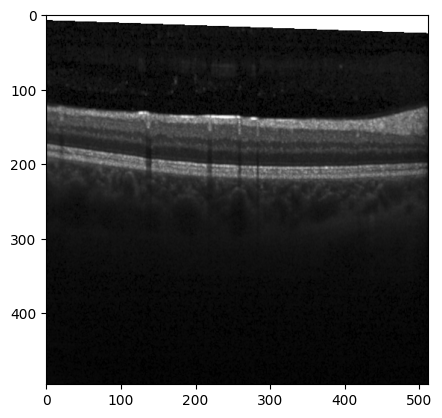

In [34]:
img = Image.open(prefix_path + "train/NORMAL/NORMAL10_019.tif")
plt.imshow(img, cmap="gray")

In [35]:
all_targets = list((Path(prefix_path) / "train").glob("*"))
label_mapping = {target.stem: i for i, target in enumerate(all_targets)}

In [36]:
model = models.resnet34(weights="ResNet34_Weights.IMAGENET1K_V1")
# model = models.resnet34(weights="DEFAULT")
# 4 classes
model.head = nn.Linear(in_features=768, out_features=3, bias=True)

In [37]:
total_params = 0
for param in model.parameters():
  if param.requires_grad:
    total_params += param.numel()
print(f" {total_params / 1e6} million params")

 21.799979 million params


In [38]:
class OCTDataset(Dataset):

  def __init__(self, root_dir, label_mapping, transform=None, format="tif"):
    self.root_dir = root_dir
    self.transform = transform
    self.num_images = None
    self.images, self.labels = [], []
    self._class_to_label = label_mapping
    self.format = format
    self._read_image_paths()

  def _read_image_paths(self):
    targets = os.listdir(self.root_dir)
    for t in targets:
      label_idx = self._class_to_label[t]
      target_dir = Path(self.root_dir) / t
      self._class_to_label[t] = label_idx
      paths = list(target_dir.glob(f"*.{self.format}"))
      self.images.extend([Image.open(p) for p in paths])
      self.labels.extend([label_idx] * len(paths))
    self.num_images = len(self.images)

  def __len__(self):
    return self.num_images

  def __getitem__(self, index) -> np.ndarray:
    return self.transform(self.images[index]), self.labels[index]

In [39]:
# Transforms: shearing, scaling, rotating and etc
# All suitable for this dataset, as they don't cause radical distribution shift for this dataset.
oct_transforms = transforms.Compose([
  transforms.Grayscale(num_output_channels=3),
  transforms.Resize((128,128)),
  transforms.RandomHorizontalFlip(0.3),
  transforms.RandomRotation(10),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.485, 0.456, 0.4], std = [0.229, 0.224, 0.225]), #imageNet mean
])

In [40]:
train_val_dataset = OCTDataset(prefix_path + "train", label_mapping=label_mapping, transform=oct_transforms, format="tif")
train_dataset, val_dataset = torch.utils.data.random_split(train_val_dataset, [0.8, 0.2], generator=torch.Generator().manual_seed(42))
test_dataset = OCTDataset(prefix_path + "test", label_mapping=label_mapping, transform=oct_transforms,format="tif")

In [41]:
len(train_dataset),len(val_dataset), len(test_dataset)

(1815, 453, 963)

In [42]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

In [43]:
next(iter(train_loader))[1]

tensor([1, 0, 0, 1, 1, 0, 2, 1, 1, 1, 1, 1, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 2, 1, 0, 2, 2, 1, 1, 0, 1, 1, 1, 0, 2, 0, 0, 0, 2, 0, 1, 0, 1, 2,
        2, 0, 1, 0, 2, 0, 0, 2, 1, 1, 0, 1, 0, 2, 1, 2])

# Task
Initialize the training components by setting the device, defining the loss function as CrossEntropyLoss, initializing the AdamW optimizer with a learning rate of 0.001 and the model's parameters, and setting up the CosineAnnealingLR scheduler with a T_max of 50. Then, install and log in to Weights & Biases, initialize a new run named "Swin-T-OCT-FineTuning", and implement the `train_one_epoch` and `validate` functions to track loss and accuracy. Finally, execute a training loop for 10 epochs, saving the model if validation loss improves. After training, summarize the achieved performance.

In [16]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/am1rrad/.netrc.
wandb: Currently logged in as: akimiyai (akimiyai-nyit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Hyperparams:


We set lr = 1e-4 since this challenge is not difficult and any lr between 1e-3 to 1e-4 should work well in practice(obviously needs tuning)
We train for 30 epochs with early stopping on validation loss(you can swap it out for val accuracy.) Optimizer is AdamW which provides strong weight decay and stability for fine-tuning jobs, and we chose batch_sz = 128 which provides more signal for the network, and we can process more images since the model is relatively small(24 million params)

In [44]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

num_epochs = 30

# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

scaler = GradScaler()
use_amp = False

model = model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")



wandb.init(project="ECGR-5116-HW1-Resnet-OCT", name=f"Resnet-OCT-{original_or_sr}-FineTuning",
          config={
        "model": "Resnet34",
        "epochs": num_epochs,
        "batch_size": 128,  # Adjust based on your DataLoader
        "learning_rate": 1e-4,
        "optimizer": "AdamW",
        "scheduler": "LR",
        "image_size": 128,
        "num_classes": 3,
        "precision": "bfloat16",
        "total_images": len(train_dataset) + len(test_dataset),
    })
wandb.watch(model, log="all", log_freq=100)

Using device: cuda:1
Model parameters: 21,799,979
Trainable parameters: 21,799,979


/tmp/ipykernel_3697603/2764160256.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [45]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch, scaler=None):
    """
    Train the model for one epoch.

    Args:
        model: The neural network model
        dataloader: Training data loader
        criterion: Loss function
        optimizer: Optimizer
        device: Device to train on
        epoch: Current epoch number
        scaler: GradScaler for mixed precision training

    Returns:
        avg_loss: Average training loss
        avg_acc: Average training accuracy
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")

    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed precision training with bfloat16
        if use_amp:
            with autocast(dtype=torch.bfloat16):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        running_loss += loss.item()

        # Update progress bar
        current_loss = running_loss / (batch_idx + 1)
        current_acc = 100 * correct / total
        pbar.set_postfix({
            'loss': f'{current_loss:.4f}',
            'acc': f'{current_acc:.2f}%',
            'lr': f'{optimizer.param_groups[0]["lr"]:.6f}'
        })

        # Log to W&B every step
        wandb.log({
            "train/step_loss": loss.item(),
            "train/step_acc": 100 * (predicted == labels).sum().item() / labels.size(0),
            "train/learning_rate": optimizer.param_groups[0]['lr']
        })

    avg_loss = running_loss / len(dataloader)
    avg_acc = 100 * correct / total

    return avg_loss, avg_acc

In [46]:
def validate(model, dataloader, criterion, device, epoch):
    """
    Validate the model.

    Args:
        model: The neural network model
        dataloader: Validation data loader
        criterion: Loss function
        device: Device to validate on
        epoch: Current epoch number

    Returns:
        avg_loss: Average validation loss
        avg_acc: Average validation accuracy
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(pbar):
            images, labels = images.to(device), labels.to(device)

            # Mixed precision inference
            if use_amp:
                with autocast(dtype=torch.bfloat16):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            running_loss += loss.item()

            # Update progress bar
            current_loss = running_loss / (batch_idx + 1)
            current_acc = 100 * correct / total
            pbar.set_postfix({
                'loss': f'{current_loss:.4f}',
                'acc': f'{current_acc:.2f}%'
            })

    avg_loss = running_loss / len(dataloader)
    avg_acc = 100 * correct / total

    return avg_loss, avg_acc

## Implement the Training Loop

### Subtask:
Execute a 10-epoch training loop, calling `train_one_epoch` and `validate` functions for each epoch. Apply the learning rate scheduler, save the model if validation loss improves, and log all relevant metrics to Weights & Biases. Finally, summarize the overall performance.

In [47]:
best_val_loss = float('inf')
best_val_acc = 0.0
patience_counter = 0
patience = 5  # Early stopping patience

print("\n" + "="*70)
print("Starting Training")
print("="*70 + "\n")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 70)

    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch, scaler
    )

    # Validate
    val_loss, val_acc = validate(
        model, val_loader, criterion, device, epoch
    )

    # Step the scheduler
    # scheduler.step()

    # Log epoch metrics to W&B
    wandb.log({
        "epoch": epoch + 1,
        "train/epoch_loss": train_loss,
        "train/epoch_acc": train_acc,
        "val/epoch_loss": val_loss,
        "val/epoch_acc": val_acc,
        "learning_rate": optimizer.param_groups[0]['lr']
    })

    # Print epoch summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        patience_counter = 0

        # Save model checkpoint
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            # 'scheduler_state_dict': scheduler.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'train_loss': train_loss,
            'train_acc': train_acc,
        }

        save_path = 'best_resnet_34.pth'
        torch.save(checkpoint, save_path)
        print(f"✓ Model saved! New best val loss: {val_loss:.4f}")

        # Save to W&B
        wandb.save(save_path)
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")

        # Early stopping check
        if patience_counter >= patience:
          print(f"\n⚠ Early stopping triggered after {epoch + 1} epochs")
          print(f"No improvement for {patience} consecutive epochs")
          break

    print("-" * 70)


Starting Training


Epoch 1/30
----------------------------------------------------------------------


Epoch 1/30 [Train]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]


Epoch 1 Summary:
Train Loss: 2.9983 | Train Acc: 62.31%
Val Loss: 0.5745 | Val Acc: 93.38%
Learning Rate: 0.000100


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


...

Epoch 9/30 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]


Epoch 9 Summary:
Train Loss: 0.0096 | Train Acc: 99.67%
Val Loss: 0.0099 | Val Acc: 99.56%
Learning Rate: 0.000100
No improvement. Patience: 4/5
----------------------------------------------------------------------

Epoch 10/30
----------------------------------------------------------------------


Epoch 10/30 [Train]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 10/30 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]


Epoch 10 Summary:
Train Loss: 0.0086 | Train Acc: 99.78%
Val Loss: 0.0180 | Val Acc: 99.78%
Learning Rate: 0.000100
No improvement. Patience: 5/5

⚠ Early stopping triggered after 10 epochs
No improvement for 5 consecutive epochs


Training Summary

In [48]:
print("\n" + "="*70)
print("Training Complete!")
print("="*70)
print(f"\nBest Validation Loss: {best_val_loss:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Model saved to: resnet_34.pth")

# Create summary table for W&B
wandb.run.summary["best_val_loss"] = best_val_loss
wandb.run.summary["best_val_acc"] = best_val_acc

# Finish W&B run
wandb.finish()

print("\n✓ Training pipeline complete!")


Training Complete!

Best Validation Loss: 0.0076
Best Validation Accuracy: 100.00%
Model saved to: resnet_34.pth


epoch,▁▂▃▃▄▅▆▆▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁
train/epoch_acc,▁█████████
train/epoch_loss,█▁▁▁▁▁▁▁▁▁
train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/step_acc,▁▂▅▇▇███████████████████████████████████
train/step_loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/epoch_acc,▁▇███▇████
val/epoch_loss,█▁▁▁▁▁▁▁▁▁
best_val_acc,100
best_val_loss,0.00759



✓ Training pipeline complete!


Now running test set

In [49]:
def get_pred_test(model, dataloader, device, use_amp=True):
    """
    Get Test prediction labels.

    Args:
        model: The neural network model
        dataloader: Test data loader
        device: Device to validate on
        use_amp: Use amp for reduced precision inference

    Returns:
      all_preds: All prediction labels
      all_labels: All ground truth labels
    """
    model.eval()
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc="[Test]")

    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(pbar):
            images, labels = images.to(device), labels.to(device)

            # Mixed precision inference
            if use_amp:
                with autocast(dtype=torch.bfloat16):
                    outputs = model(images)
            else:
                outputs = model(images)

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            # Update progress bar

    return all_preds, all_labels

[Test]:   0%|          | 0/16 [00:00<?, ?it/s]

test accuracy: 98.75389408099689 %


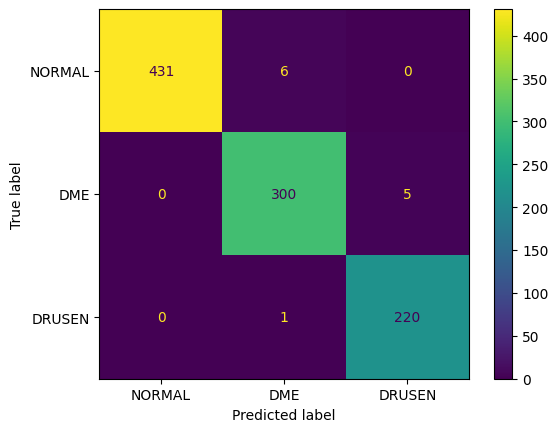

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
model.load_state_dict(torch.load("./wandb/latest-run/files/best_resnet_34.pth", weights_only=False), strict=False)
all_preds, all_labels = get_pred_test(model, test_loader, device, use_amp=False)
acc = (np.array(all_preds) == np.array(all_labels)).sum() / len(all_labels)
print (f"test accuracy: {acc * 100} %")
conf_mat = confusion_matrix(np.array(all_labels), np.array(all_preds))
classes_ordered = label_mapping.keys()
disp = ConfusionMatrixDisplay(conf_mat, display_labels=classes_ordered)
disp.plot()
# save confusion matrix to disk
plt.savefig(f"results/classification/{original_or_sr}/confusion_matrix.png")

              precision    recall  f1-score   support

      NORMAL       1.00      0.99      0.99       437
         DME       0.98      0.98      0.98       305
      DRUSEN       0.98      1.00      0.99       221

    accuracy                           0.99       963
   macro avg       0.98      0.99      0.99       963
weighted avg       0.99      0.99      0.99       963

F1 Score: 0.9867


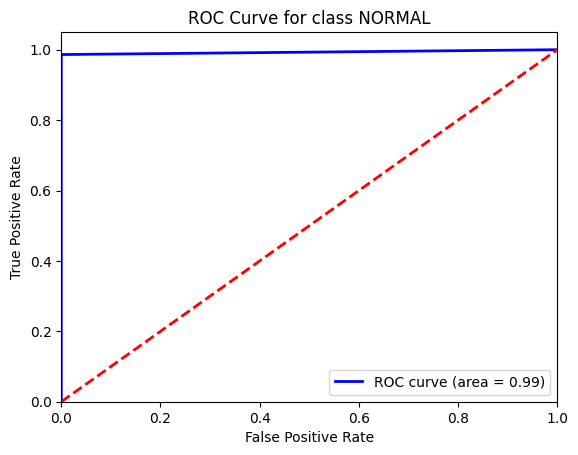

<Figure size 640x480 with 0 Axes>

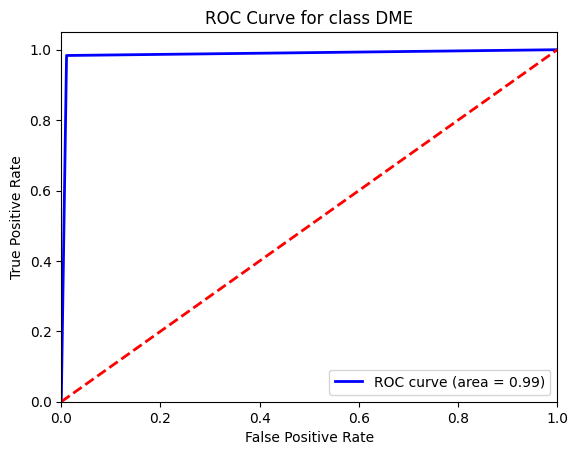

<Figure size 640x480 with 0 Axes>

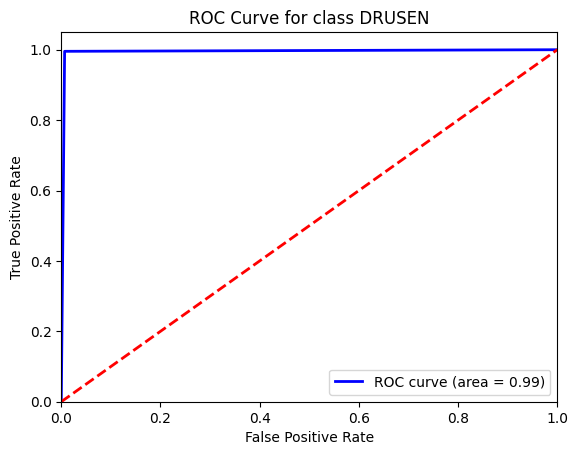

<Figure size 640x480 with 0 Axes>

In [52]:
# compute f1 score
from sklearn.metrics import f1_score, classification_report
print(classification_report(all_labels, all_preds, target_names=classes_ordered))
print(f"F1 Score: {f1_score(all_labels, all_preds, average='macro'):.4f}")

# plot aoc-ruc curve for each class
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay
y_true_bin = label_binarize(all_labels, classes=list(label_mapping.values()))
y_score_bin = label_binarize(all_preds, classes=list(label_mapping.values()))
for i in range(len(label_mapping)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score_bin[:, i])
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for class {list(classes_ordered)[i]}')
    plt.legend(loc="lower right")
    plt.show()
    plt.savefig(f"results/classification/{original_or_sr}/roc_curve_{list(classes_ordered)[i]}.png")


